# VTuber 1B: Live Chat Analytics

A directory of 32GB unified parquet file were initially preprocessed due to inconsistent

In [1]:
from pyspark.sql.functions import (
    col, count, avg, max, when, desc, lit,
    approx_count_distinct,
    broadcast,
    sum as spark_sum,
    collect_set,
    size,
    array_distinct,
    flatten,
    collect_list
)

from pyspark.sql import DataFrame
from pyspark.sql.window import Window
from pyspark.sql.functions import rank
from pyspark.sql import Row

import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("VTuber_Analytics")
    .master("local[*]") 
    .config("spark.driver.memory", "10g")
    .config(
        "spark.driver.extraJavaOptions",
        "-XX:+UseG1GC -XX:InitiatingHeapOccupancyPercent=35"
    )
    # Keep chunks small for memory safety
    .config("spark.sql.files.maxPartitionBytes", "67108864")  
    # Arrow makes the Spark -> Pandas transfer 10x to 100x faster.
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.shuffle.partitions", "1000")
    # Give the Driver a bit more breathing room when collecting final results for plotting.
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)

In [3]:
#Loading datasets
source = '/mnt/processed/private/msds2026/slt9a/unified_chats_2021'
source_2 = '/mnt/processed/private/msds2026/slt9a/channels_2021.csv'
chats = spark.read.parquet(source)
channels = spark.read.csv(
    source_2,
    header=True,
    inferSchema=True)

chats.createOrReplaceTempView('chats')
channels.createOrReplaceTempView('channels')

chats.printSchema()
channels.printSchema()

root
 |-- timestamp: timestamp (nullable = true)
 |-- authorChannelId: string (nullable = true)
 |-- videoId: string (nullable = true)
 |-- channelId: string (nullable = true)
 |-- bodyLength: long (nullable = true)

root
 |-- _c0: integer (nullable = true)
 |-- channelId: string (nullable = true)
 |-- name: string (nullable = true)
 |-- englishName: string (nullable = true)
 |-- affiliation: string (nullable = true)
 |-- videoCount: integer (nullable = true)



In [4]:
channels.show(5)

+---+--------------------+----------------------------+--------------------+-----------+----------+
|_c0|           channelId|                        name|         englishName|affiliation|videoCount|
+---+--------------------+----------------------------+--------------------+-----------+----------+
|  0|UCJFZiqLMntJufDCH...|   hololive ホロライブ - ...|Hololive VTuber G...|   Hololive|       509|
|  1|UCfrWoRGlawPQDQxx...|          hololive Indonesia|  Hololive Indonesia|   Hololive|        69|
|  2|UCotXwY6s8pWmuWd_...|            hololive English|    Hololive English|   Hololive|        34|
|  3|UCWsfcksUUpoEvhia...|  holostars ホロスターズ ...|  Holostars Official|   Hololive|       150|
|  4|UCp6993wxpyDPHUpa...|SoraCh. ときのそらチャンネル|         Tokino Sora|   Hololive|       667|
+---+--------------------+----------------------------+--------------------+-----------+----------+
only showing top 5 rows


In [5]:
def most_channel():
    """
    Which VTuber channels receive the most channels?
    """

    query = """
    SELECT channels.englishName as `English Name`, COUNT(*) as `Total Chats`
    FROM chats
    JOIN channels
    ON chats.channelId = channels.channelId
    GROUP BY channels.englishName
    ORDER BY `Total Chats` DESC
    LIMIT 20;
    """
    
    return spark.sql(query)

In [6]:
q1 = most_channel()
q1.show()

+----------------+-----------+
|    English Name|Total Chats|
+----------------+-----------+
|    Usada Pekora|   31144439|
|     Sakura Miko|   18542086|
|       Gawr Gura|   14632354|
| Takanashi Kiara|   13825699|
|   Oozora Subaru|   13272619|
|   Yukihana Lamy|   12801025|
|    Uruha Rushia|   12543306|
|Tsunomaki Watame|   12109778|
|  Houshou Marine|   11744882|
|   Watson Amelia|   11272410|
|          Kuzuha|   11165917|
|  Inugami Korone|   11019240|
|    Amane Kanata|    9697269|
|           Kanae|    9187275|
| Ninomae Ina’nis|    8529349|
|Shirakami Fubuki|    8512457|
|      Kiryu Coco|    8232139|
|   Mori Calliope|    8223660|
|     Fuwa Minato|    8119214|
|  Nekomata Okayu|    8070036|
+----------------+-----------+



In [7]:
def mo_stream_chats():
    """
    How many stream chats done per month of the year 2021?
    """

    query = """
    SELECT 
        DATE_FORMAT(timestamp, 'yyyy-MM') AS `year-month`,
        COUNT(*) AS total_chats
    FROM chats
    GROUP BY DATE_FORMAT(timestamp, 'yyyy-MM')
    ORDER BY `year-month`;
    """
    return spark.sql(query)

In [8]:
q2 = mo_stream_chats()
q2.show()

+----------+-----------+
|year-month|total_chats|
+----------+-----------+
|   2021-01|    1998144|
|   2021-02|   30707138|
|   2021-03|   67126793|
|   2021-04|   63446229|
|   2021-05|   75898905|
|   2021-06|   75388311|
|   2021-07|   80829747|
|   2021-08|   99281411|
|   2021-09|   87760727|
|   2021-10|   83370517|
|   2021-11|   81942259|
|   2021-12|     591577|
+----------+-----------+



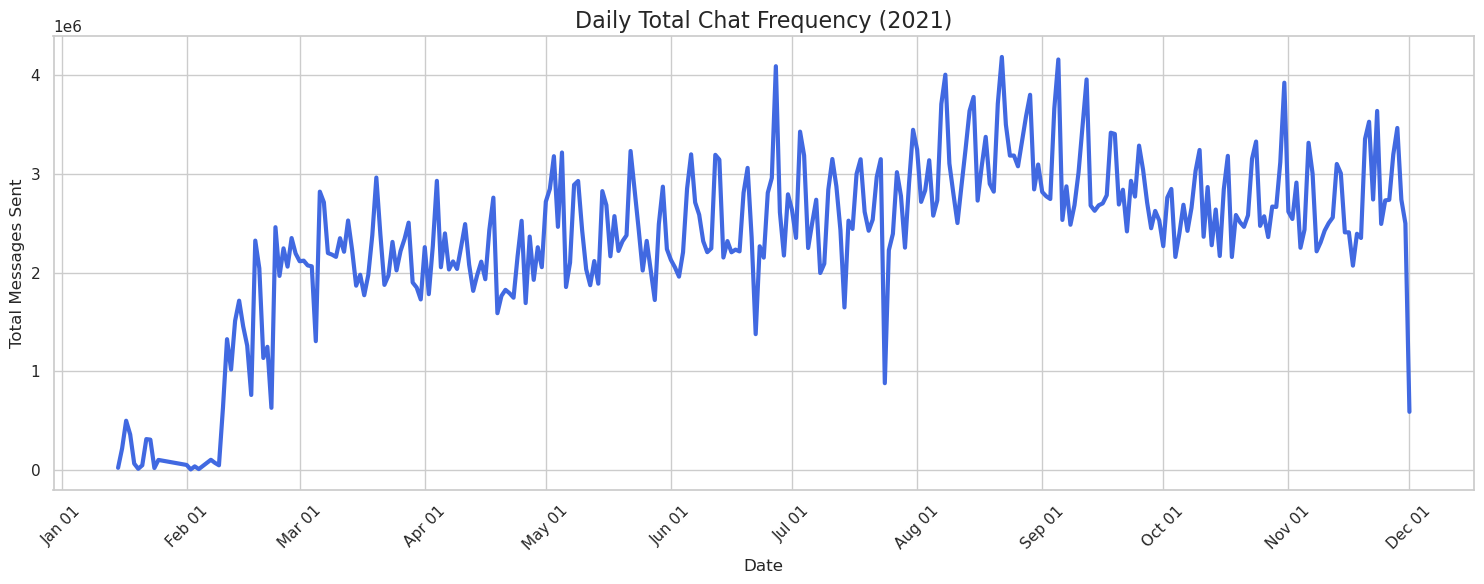

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Spark does the heavy lifting: Filter for 2021 and group by day
def daily_chats():
    """
    How does chat frequency change over time?
    """
    query = """
    SELECT DATE(timestamp) AS chat_date,
           COUNT(*) AS daily_chats
    FROM chats
    GROUP BY DATE(timestamp)
    ORDER BY chat_date;
    """
    return spark.sql(query)

# Safely collect the ~365 rows to the Driver's RAM
q3_df = daily_chats().toPandas()


# Set the theme for a professional look
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 6))

# Create the line plot
line_plot = sns.lineplot(data=q3_df, x='chat_date', y='daily_chats', color='royalblue', linewidth=3)

# Improve Date Formatting on X-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d')) # Shows "Jan 01"
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())          # Tick marks at every month

plt.title('Daily Total Chat Frequency (2021)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Messages Sent', fontsize=12)

# Rotate labels so they don't overlap
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

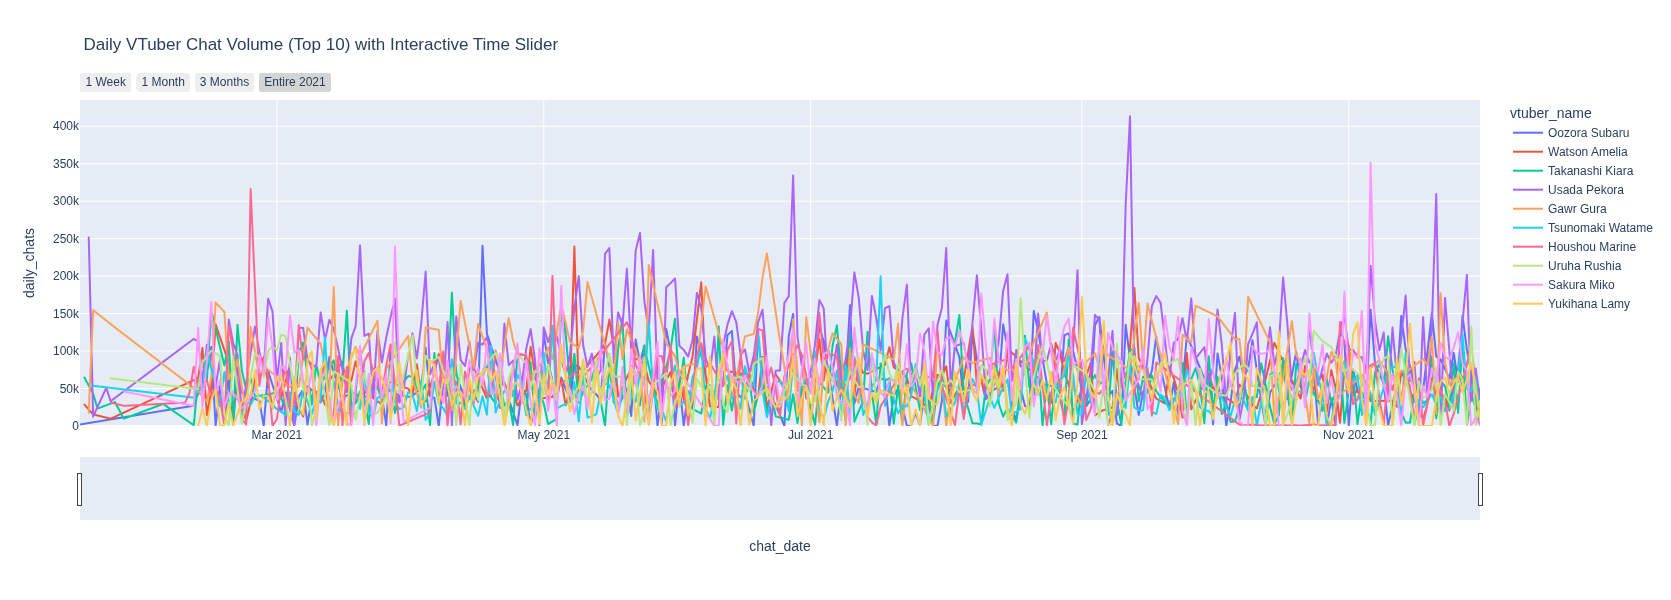

In [10]:
# 1. Spark does the heavy lifting: Find Top 10, Join, and Group

def vtuber_daily():
    """doctring"""
    
    query = """
    -- Step A: Find the Top 10 Channels by total chat volume
    WITH Top10Channels AS (
        SELECT channelId, COUNT(*) as total_chats
        FROM chats
        GROUP BY channelId
        ORDER BY total_chats DESC
        LIMIT 10
    )
    -- Step B: Join that top 10 list with the main data and channels table
    SELECT DATE(c.timestamp) AS chat_date,
           ch.englishName AS vtuber_name,
           COUNT(*) AS daily_chats
    FROM chats c
    JOIN channels ch ON c.channelId = ch.channelId
    JOIN Top10Channels t ON c.channelId = t.channelId
    GROUP BY DATE(c.timestamp), ch.englishName
    ORDER BY chat_date;
    """
    return spark.sql(query)


# 2. Collect the summarized data (roughly 365 days * 10 VTubers = ~3,650 rows)
q3_modified_df = vtuber_daily().toPandas()

# 3. Build the Plotly Line Chart
fig = px.line(
    q3_modified_df,
    x='chat_date',
    y='daily_chats',
    color='vtuber_name',
    title='Daily VTuber Chat Volume (Top 10) with Interactive Time Slider',
    width=1500,
    height=600
)

# 4. Add back your Range Slider and Quick-Select Buttons
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=7, label="1 Week", step="day", stepmode="backward"),
            dict(count=1, label="1 Month", step="month", stepmode="backward"),
            dict(count=3, label="3 Months", step="month", stepmode="backward"),
            dict(step="all", label="Entire 2021")
        ])
    )
)

# 5. Clean up the Y-axis
fig.update_yaxes(rangemode="tozero")

# 6. Display in Colab
display(fig)

In [11]:
vtuber_daily().show(50)

+----------+----------------+-----------+
| chat_date|     vtuber_name|daily_chats|
+----------+----------------+-----------+
|2021-01-15|   Oozora Subaru|       2015|
|2021-01-16|   Watson Amelia|      28653|
|2021-01-16| Takanashi Kiara|      64832|
|2021-01-17|    Usada Pekora|     251729|
|2021-01-17|       Gawr Gura|      17713|
|2021-01-18|   Watson Amelia|      15517|
|2021-01-18|Tsunomaki Watame|      53645|
|2021-01-18|       Gawr Gura|     154646|
|2021-01-18|    Usada Pekora|      12474|
|2021-01-18| Takanashi Kiara|      43202|
|2021-01-19| Takanashi Kiara|      23299|
|2021-01-21|    Usada Pekora|      50936|
|2021-01-22|  Houshou Marine|      31455|
|2021-01-22|   Watson Amelia|       9709|
|2021-01-22|    Usada Pekora|      33095|
|2021-01-22|    Uruha Rushia|      63625|
|2021-01-23| Takanashi Kiara|      31974|
|2021-01-23|       Gawr Gura|     131495|
|2021-01-25| Takanashi Kiara|       9697|
|2021-01-25|  Houshou Marine|      26947|
|2021-01-25|     Sakura Miko|     

In [13]:
# Are longer chats more common in some streams or channels?

def long_chat():
    """
    Are longer chats more common in some streams or channels?
    """
    query = """
    SELECT ch.englishName AS `English Name`,
        AVG(c.bodyLength) AS avg_chat_length,
        COUNT(*) AS total_chats
    FROM chats c
    JOIN channels ch
    ON c.channelId = ch.channelId
    GROUP BY ch.englishName
    HAVING total_chats > 5000  -- Filters out low-chat anomalies
    ORDER BY avg_chat_length DESC;
    """
    return spark.sql(query)

In [15]:
long_chat().show(20, truncate=False)

+---------------+------------------+-----------+
|English Name   |avg_chat_length   |total_chats|
+---------------+------------------+-----------+
|Walfie         |34.25545092586741 |15823      |
|Europa         |30.256508875739645|6760       |
|Ushio Ebi      |27.13420306398048 |222521     |
|Pipkin Pippa   |26.941926459667343|335299     |
|Orla Gan Ceann |26.629163400680884|85477      |
|Kaga Oren      |25.966904345486345|22299      |
|Tsurugi Nen    |25.54158964879852 |7033       |
|Cecile         |25.038280616382806|24660      |
|Yazaki Kallin  |25.01006081654584 |128419     |
|FruFru VTubers |24.907278733340927|17558      |
|Jaret Fajrianto|24.826221939181657|12562      |
|Shee Icho      |24.79529848937717 |61895      |
|Fujikura Uruka |24.738833804454725|161671     |
|Tetsuya Kazune |24.548014359434596|26742      |
|Mana Renewal   |24.499610776369554|360975     |
|Kyria          |24.15782109345106 |175097     |
|Rinkou Ashelia |24.148406902441177|135836     |
|Kitsui Akira   |23.